<a href="https://colab.research.google.com/github/Tanzeela00Sharif/python-notebooks-collection/blob/main/pivot_table.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns

In [14]:
df=sns.load_dataset('tips').head()
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [15]:
10.34 +21.01+ 23.68

55.03

In [16]:
#which gender pay more bill
df.groupby('sex')[['total_bill']].mean()

/tmp/ipykernel_1603/1582738739.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,18.343333
Female,20.790000


In [17]:
#which gender pay more bill and that is smoker or non smoker
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

/tmp/ipykernel_1603/668581866.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male          NaN  18.343333
Female        NaN  20.790000

##Pivot table

In [18]:
df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')

/tmp/ipykernel_1603/3627826641.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex',columns='smoker',values='total_bill',aggfunc='sum')


smoker,Yes,No
sex,,
Male,0.0,55.03
Female,0.0,41.58


In [19]:
df.pivot_table(index='time',columns='total_bill',values='size').unstack()

/tmp/ipykernel_1603/1871630499.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='time',columns='total_bill',values='size').unstack()


,,0
total_bill,time,
10.34,Dinner,3.0
16.99,Dinner,2.0
21.01,Dinner,3.0
23.68,Dinner,2.0
24.59,Dinner,4.0


In [20]:
df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'tip':'mean','total_bill':'sum'})

/tmp/ipykernel_1603/534012754.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index=['sex','smoker'],columns=['day','time'],aggfunc={'tip':'mean','total_bill':'sum'})


tip total_bill                                         \
day                 Sun       Thur          Fri          Sat          Sun   
time             Dinner      Lunch Dinner Lunch Dinner Lunch Dinner Lunch   
sex    smoker                                                               
Male   Yes          NaN        0.0    0.0   0.0    0.0   0.0    0.0   0.0   
       No      2.823333        0.0    0.0   0.0    0.0   0.0    0.0   0.0   
Female Yes          NaN        0.0    0.0   0.0    0.0   0.0    0.0   0.0   
       No      2.310000        0.0    0.0   0.0    0.0   0.0    0.0   0.0   

                      
day                   
time          Dinner  
sex    smoker         
Male   Yes      0.00  
       No      55.03  
Female Yes      0.00  
       No      41.58

In [24]:
expense= pd.read_csv('/content/expense_data.csv')
expense.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [27]:
expense['Category'].value_counts()

,count
Category,
Food,156
Other,60
Transportation,31
Apparel,7
Household,6
Allowance,6
Social Life,5
Education,1
Salary,1


In [28]:
expense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [31]:
expense['Date']=pd.to_datetime(expense['Date'])

In [33]:
expense.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [35]:
#extract month name
expense['Month']=expense['Date'].dt.month_name()

In [36]:
expense

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March
...,...,...,...,...,...,...,...,...,...,...,...,...
272,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Dinner,90.0,Expense,NaN,90.0,INR,90.0,November
273,2021-11-22 14:16:00,CUB - online payment,Food,NaN,Lunch with company,97.0,Expense,NaN,97.0,INR,97.0,November
274,2021-11-21 17:07:00,CUB - online payment,Transportation,NaN,Rapido,130.0,Expense,NaN,130.0,INR,130.0,November
275,2021-11-21 15:50:00,CUB - online payment,Food,NaN,Lunch,875.0,Expense,NaN,875.0,INR,875.0,November


/tmp/ipykernel_1603/1457029782.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  expense.pivot_table(index='Month',columns='Category',values='INR',aggfunc='sum',margins=True,fill_value='0').plot()


<Axes: xlabel='Month'>

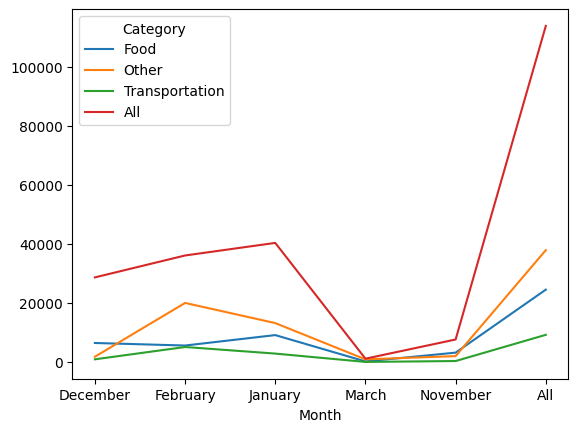

In [44]:
expense.pivot_table(index='Month',columns='Category',values='INR',aggfunc='sum',margins=True,fill_value='0').plot()

In [45]:
expense.columns

Index(['Date', 'Account', 'Category', 'Subcategory', 'Note', 'INR',
       'Income/Expense', 'Note.1', 'Amount', 'Currency', 'Account.1', 'Month'],
      dtype='object')

<Axes: xlabel='Month'>

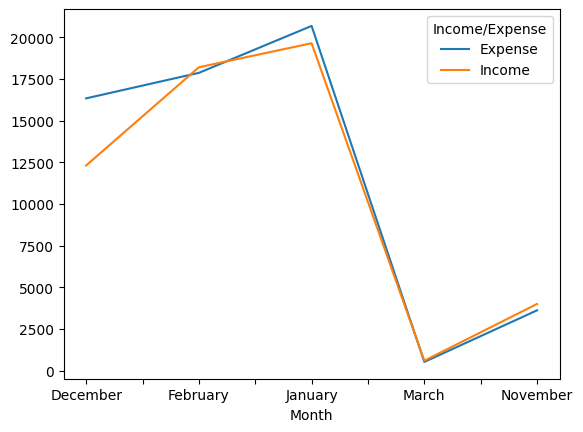

In [47]:
expense.pivot_table(index='Month',columns='Income/Expense',values='INR',aggfunc='sum').plot()

<Axes: xlabel='Month'>

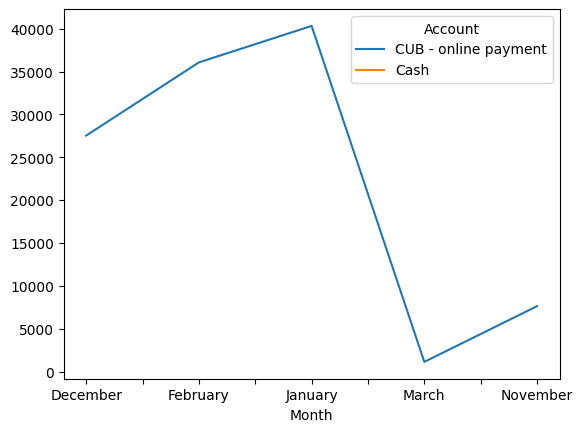

In [50]:
expense.pivot_table(index='Month',columns='Account',values='INR',aggfunc='sum').plot()